### Business Case: 
FicZon Inc is an IT solution provider with products ranging from onpremises products to SAAS based solutions. FicZon major leads generation channel is digital and through their website. FicZon business is majorly dependent on the sales force effectiveness. As the market is maturing and more new competitors 
entering the market, FicZon is experiencing the dip in sales. 
Effective sales is dependent on lead quality and as of now, this is 
based on manual categorization and highly depended on sales staff. 
Though there is a quality process, which continuously updates the 
lead categorization, it’s value is in for post analysis, rather than 
conversation.
FicZon wants to explore Machine Learning to pre-categorize the lead 
quality and as result, expecting significant increase in sales 
effectiveness.


In [1]:
#import libaries
import pandas as pd
import numpy as npyu
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import  warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [2]:
#import data
data =pd.read_csv("business_data.csv")
data


,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
...,...,...,...,...,...,...,...,...,...
7417,28-04-2018 09:45,9.0,Call,NaN,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15.0,Call,NaN,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5.0,Live Chat-Direct,NaN,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21.0,CRM form,NaN,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry


In [3]:
data.shape

(7422, 9)

In [4]:
data.head(5)

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open


In [5]:
data.tail(5)

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9.0,Call,NaN,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15.0,Call,NaN,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5.0,Live Chat-Direct,NaN,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21.0,CRM form,NaN,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25.0,Website,NaN,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


## basic checkes

In [6]:
data.columns

Index(['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent',
       'Location', 'Delivery_Mode', 'Status'],
      dtype='object')

In [7]:
data.dtypes

Created           object
Product_ID       float64
Source            object
Mobile            object
EMAIL             object
Sales_Agent       object
Location          object
Delivery_Mode     object
Status            object
dtype: object

#### In the dataset there was only one float value and remaining columns are object data types  

In [8]:
data.isnull().sum()

Created             0
Product_ID         58
Source             17
Mobile           1810
EMAIL               0
Sales_Agent        23
Location           58
Delivery_Mode       0
Status              0
dtype: int64

<Axes: >

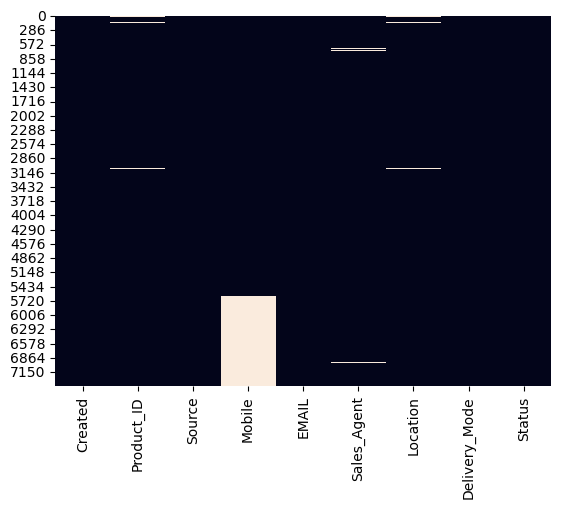

In [9]:
sns.heatmap(data.isnull(),cbar=False)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Created        7422 non-null   object 
 1   Product_ID     7364 non-null   float64
 2   Source         7405 non-null   object 
 3   Mobile         5612 non-null   object 
 4   EMAIL          7422 non-null   object 
 5   Sales_Agent    7399 non-null   object 
 6   Location       7364 non-null   object 
 7   Delivery_Mode  7422 non-null   object 
 8   Status         7422 non-null   object 
dtypes: float64(1), object(8)
memory usage: 522.0+ KB


In [11]:
data.describe()

,Product_ID
count,7364.000000
mean,15.947311
std,6.072937
min,0.000000
25%,12.000000
50%,18.000000
75%,19.000000
max,28.000000


In [12]:
data_col=data.columns.value_counts().index

In [13]:
data.drop(['Created'],axis=1,inplace=True)
data.drop(['Mobile'],axis=1,inplace=True)
data.drop(['EMAIL'],axis=1,inplace=True)



In [14]:
data

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
0,NaN,Website,Sales-Agent-11,NaN,Mode-5,Open
1,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
2,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
3,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
4,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
...,...,...,...,...,...,...
7417,9.0,Call,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,15.0,Call,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,5.0,Live Chat-Direct,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,21.0,CRM form,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry


In [15]:
data.replace('',np.nan,inplace=True)
data.dropna(inplace=True)
data.reset_index(inplace=True,drop=True)


In [16]:
data.shape

(7328, 6)

In [17]:
data


,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
0,9.0,Live Chat-Google Organic,Sales-Agent-3,Bangalore,Mode-1,Potential
1,19.0,Call,Sales-Agent-4,Other Locations,Mode-5,Potential
2,18.0,Website,Sales-Agent-11,Trivandrum,Mode-1,Potential
3,15.0,Website,Sales-Agent-7,Hyderabad,Mode-1,Not Responding
4,18.0,Call,Sales-Agent-7,Bangalore,Mode-1,In Progress Positive
...,...,...,...,...,...,...
7323,9.0,Call,Sales-Agent-6,Mumbai,Mode-4,LOST
7324,15.0,Call,Sales-Agent-12,Other Locations,Mode-5,LOST
7325,5.0,Live Chat-Direct,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7326,21.0,CRM form,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry


In [18]:
data.Product_ID.value_counts().index

Index([18.0, 15.0, 19.0,  9.0, 27.0,  5.0, 10.0,  1.0, 20.0, 25.0, 21.0,  2.0,
       12.0, 26.0, 14.0, 11.0, 22.0,  3.0,  6.0,  8.0, 17.0, 13.0, 16.0, 24.0,
       23.0,  0.0, 28.0,  7.0,  4.0],
      dtype='float64', name='Product_ID')

In [19]:
data.Source.value_counts().index

Index(['Call', 'Live Chat-Direct', 'Website', 'Live Chat-Google Organic',
       'Live Chat -PPC', 'Live Chat-Blog', 'Customer Referral', 'US Website',
       'Just Dial', 'Existing Client', 'Personal Contact', 'Live Chat-CPC',
       'By Recommendation', 'Existing Customer', 'CRM form',
       'Live Chat-Google Ads', 'Campaign', 'E-mail Campaign',
       'Live Chat-Adwords Remarketing', 'Live Chat-Quora', 'Other',
       'SMS Campaign', 'Live Chat-Youtube', 'E-Mail Message',
       'Live Chat-Justdial'],
      dtype='object', name='Source')

In [20]:
data.Source.replace(['Live Chat-Direct','Live Chat-Google Organic','Live Chat -PPC','Live Chat-Blog','Live Chat-CPC',
            'Live Chat-Google Ads','Live Chat-Adwords Remarketing','Live Chat-Quora','Live Chat-Justdial','Live Chat-Youtube',''],'Live Chat',inplace=True)
data.Source.replace(['Existing Client','CRM form','Personal Contact'],'Existing Customer',inplace=True)
data.Source.replace(['By Recommendation','Customer Referral'],inplace=True)
data.Source.replace(['US Website','Just Dial'],'Website',inplace=True)
data.Source.replace(['E-mail Campaign','SMS Campaign','E-Mail Message','Other'],'Campaign',inplace=True)

In [21]:
data.Source.value_counts()

Source
Live Chat            2764
Call                 2587
Website              1789
Existing Customer     147
Campaign               41
Name: count, dtype: int64

In [22]:
data.Location.value_counts().index

Index(['Other Locations', 'Bangalore', 'Chennai', 'Hyderabad', 'Delhi',
       'Mumbai', 'Pune', 'UAE', 'Trivandrum', 'Kolkata', 'USA', 'UK',
       'AUSTRALIA', 'Singapore', 'Malaysia', 'EUROPE', 'Howrah'],
      dtype='object', name='Location')

In [23]:
data.Location.replace(['USA','UK','AUSTRALIA','Singapore','Malaysia','EUROPE','UAE'],'Forgin',inplace=True)
data.Location.replace(['Trivandrum','Kolkata','Howrah'],'Other Locations',inplace=True)

In [24]:
data.Location.value_counts().index

Index(['Other Locations', 'Bangalore', 'Chennai', 'Hyderabad', 'Delhi',
       'Mumbai', 'Forgin', 'Pune'],
      dtype='object', name='Location')

In [25]:
data.Product_ID.value_counts().index

Index([18.0, 15.0, 19.0,  9.0, 27.0,  5.0, 10.0,  1.0, 20.0, 25.0, 21.0,  2.0,
       12.0, 26.0, 14.0, 11.0, 22.0,  3.0,  6.0,  8.0, 17.0, 13.0, 16.0, 24.0,
       23.0,  0.0, 28.0,  7.0,  4.0],
      dtype='float64', name='Product_ID')

In [26]:
data.Product_ID.replace(['8','6','3','17','22','11','7','28','0','23','24','16','13','4','14','26','12','2','21','25'],
                        'Less Sold Product',inplace=True)


In [27]:
data.Product_ID.value_counts()

Product_ID
18.0    1706
15.0    1501
19.0    1188
9.0      990
27.0     737
5.0      484
10.0     168
1.0      104
20.0     101
25.0      90
21.0      65
2.0       38
12.0      36
26.0      31
14.0      27
11.0      12
22.0       8
3.0        7
6.0        7
8.0        6
17.0       6
13.0       4
16.0       3
24.0       2
23.0       2
0.0        2
28.0       1
7.0        1
4.0        1
Name: count, dtype: int64

In [28]:
data.tail(20)

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
7308,9.0,Live Chat,Sales-Agent-11,Other Locations,Mode-1,CONVERTED
7309,19.0,Live Chat,Sales-Agent-9,Bangalore,Mode-1,CONVERTED
7310,19.0,Call,Sales-Agent-9,Bangalore,Mode-1,CONVERTED
7311,18.0,Live Chat,Sales-Agent-3,Bangalore,Mode-1,Junk Lead
7312,18.0,Live Chat,Sales-Agent-2,Hyderabad,Mode-1,LOST
7313,15.0,Live Chat,Sales-Agent-7,Bangalore,Mode-1,Not Responding
7314,10.0,Call,Sales-Agent-9,Chennai,Mode-4,Long Term
7315,19.0,Call,Sales-Agent-2,Bangalore,Mode-4,Long Term
7316,18.0,Call,Sales-Agent-4,Bangalore,Mode-1,CONVERTED
7317,5.0,Live Chat,Sales-Agent-7,Hyderabad,Mode-1,Just Enquiry


In [29]:
data.Status.value_counts().index

Index(['Junk Lead', 'Not Responding', 'CONVERTED', 'Just Enquiry', 'Potential',
       'Long Term', 'In Progress Positive', 'In Progress Negative', 'LOST',
       'Open', 'converted'],
      dtype='object', name='Status')

In [30]:
data.Status.replace(['CONVERTED','converted','In Progress Positive','Potential','Long Term','Open'],'Good',inplace=True)
data.Status.replace(['Junk Lead','Not Responding','Just Enquiry','In Progress Negative','LOST'],'Bad',inplace=True)

In [31]:
data.Status.value_counts().index

Index(['Bad', 'Good'], dtype='object', name='Status')

<Axes: xlabel='Delivery_Mode'>

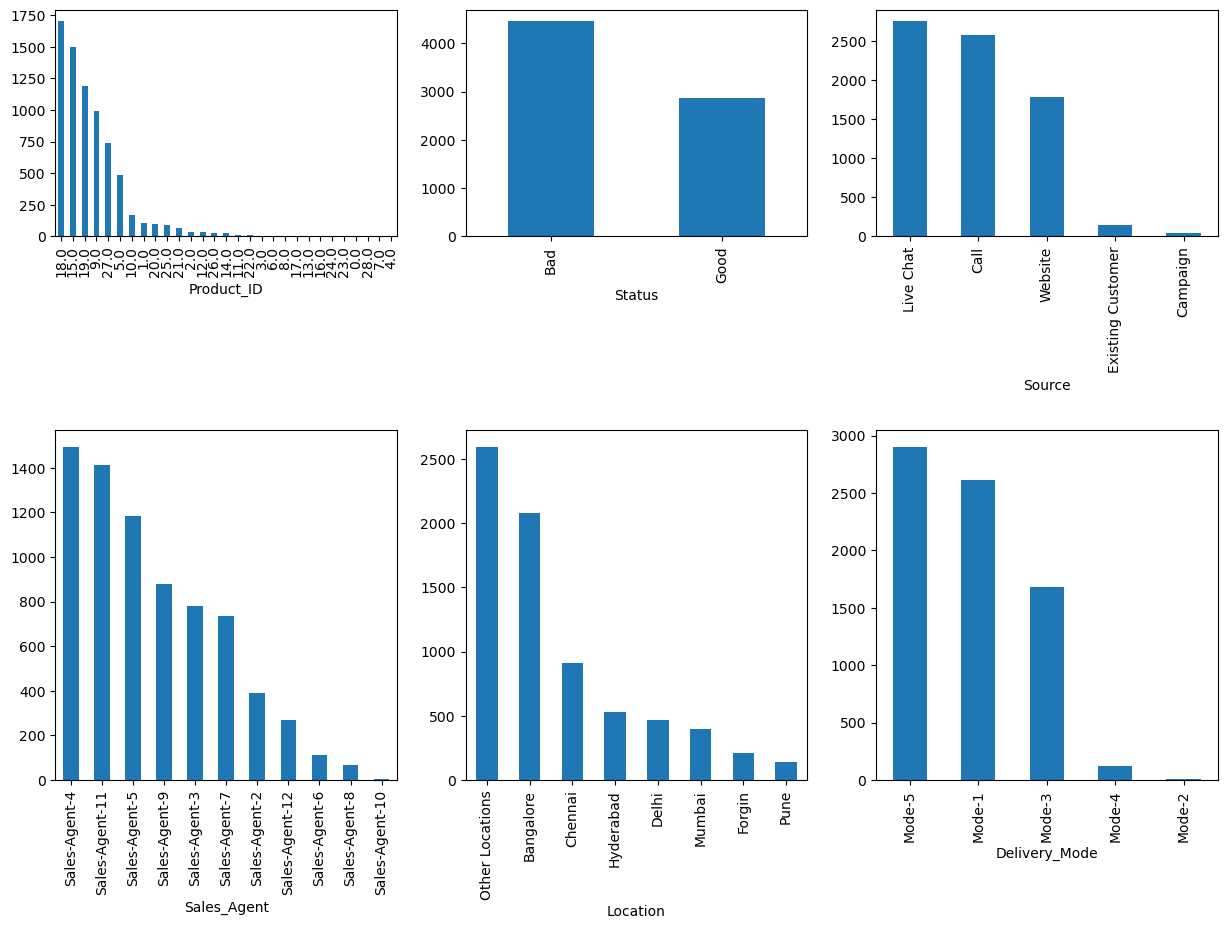

In [32]:
plt.figure(figsize=(15,10))
plt.subplot(3,3,1)
data.Product_ID.value_counts().plot(kind='bar')
plt.subplot(3,3,2)
data.Status.value_counts().plot(kind='bar')
plt.subplot(3,3,3)
data.Source.value_counts().plot(kind='bar')
plt.subplot(2,3,4)
data.Sales_Agent.value_counts().plot(kind='bar')
plt.subplot(2,3,5)
data.Location.value_counts().plot(kind='bar')
plt.subplot(2,3,6)
data.Delivery_Mode.value_counts().plot(kind='bar')


In [53]:
enc=LabelEncoder()
for i in  (0,1,2,3,4,5):
        data.iloc[:,i] = enc.fit_transform(data.iloc[:,i])
data.head()

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
0,9.0,3,4,0,0,1
1,19.0,0,5,6,4,1
2,18.0,4,1,6,0,1
3,15.0,4,8,4,0,0
4,18.0,0,8,0,0,1


In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7328 entries, 0 to 7327
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     7328 non-null   float64
 1   Source         7328 non-null   object 
 2   Sales_Agent    7328 non-null   object 
 3   Location       7328 non-null   object 
 4   Delivery_Mode  7328 non-null   object 
 5   Status         7328 non-null   object 
dtypes: float64(1), object(5)
memory usage: 343.6+ KB


In [35]:
data.corr()

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
Product_ID,1.000000,0.061658,0.006529,-0.041902,-0.036025,0.085415
Source,0.061658,1.000000,-0.024505,-0.008013,-0.212156,-0.003233
Sales_Agent,0.006529,-0.024505,1.000000,-0.140876,-0.224688,0.137074
Location,-0.041902,-0.008013,-0.140876,1.000000,0.414193,-0.347418
Delivery_Mode,-0.036025,-0.212156,-0.224688,0.414193,1.000000,-0.220445
Status,0.085415,-0.003233,0.137074,-0.347418,-0.220445,1.000000


In [36]:
y=data.Status
x=data.iloc[:,[0,1,2,3,4]]

In [63]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=10)

In [56]:
X_train.shape

(5862, 5)

In [57]:
X_test.shape

(1466, 5)

In [58]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [41]:
pip install --upgrade imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [59]:
smote = SMOTE(random_state=1)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train.astype(int))

In [60]:
X_resampled.shape

(7192, 5)

In [61]:
X_test.shape

(1466, 5)

### MODEL
### Logistic Regression 

In [72]:
from sklearn.linear_model import LogisticRegression
model_logr = LogisticRegression()
model_logr.fit(X_train,y_train)

ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.